# Problem set #2
By: Aske Roelshøj (KVF851)

Date: 25/02 2026

In [4]:
import numpy as np
import pandas as pd 
from scipy import stats
from scipy.stats import mode
from scipy.special import gamma
r = np.random
r.seed(1)
from scipy.optimize import minimize
from iminuit import Minuit, cost
from scipy.integrate import quad
from numba import njit

#matplotlibs: 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms


In [5]:
xkcd_names = ["grape", "dark forest green", "indigo", "brick", "cobalt", "blueberry", "blood red", "deep orange","black", "dark fuchsia", "eggplant purple", "deep aqua", "british racing green", "teal blue", "berry", "bright lavender", "cherry red", "pine", "shit", "electric blue"]
colors = [f"xkcd:{name}" for name in xkcd_names]

## Problem 1a

In [6]:
def gev_model(x, mu, sigma, xi):
    t = (1+xi*((x-mu)/sigma))**(-1/xi)
    return (1/sigma) * t**(xi+1)*np.exp(-t)

In [7]:
#Load data (ignore nan in club atm): 
times_10k = pd.read_csv('Liverpool10k2026.csv')
times_10k_vals = times_10k['Time'].values
#Let us clean the times, and only get the times in seconds:
def time_to_seconds(times):
    time_parts = times.split(':')
    if len(time_parts) == 3:
        hours, minutes, seconds = time_parts
        total_seconds = int(hours) * 3600 + int(minutes) * 60 + float(seconds)
    elif len(time_parts) == 2:
        minutes, seconds = time_parts
        total_seconds = int(minutes) * 60 + float(seconds)
    else:
        raise ValueError("Invalid time format")
    return total_seconds
#Had to fix to entries
times_10k_seconds = np.array([time_to_seconds(times_10k_vals[i]) for i in range(len(times_10k_vals))])

In [21]:
print(len(times_10k_seconds))

198


In [8]:
def minimizer_gev(samples, init_params):
    neg_llhs = []

    mu_init, sigma_init, xi_init = init_params

    def neg_log_likelihood(mu, sigma, xi):
        neg_log_likelihood = -np.sum(np.log(gev_model(samples, mu, sigma, xi)))
        neg_llhs.append(neg_log_likelihood)
        return neg_log_likelihood
    
    m = Minuit(neg_log_likelihood, mu_init, sigma_init, xi_init)
    m.limits["xi"] = (-1, 0)  # Set limits for xi to ensure valid GEV parameters

    m.migrad()  # Minimize

    params_est = m.values
    params_err = m.errors

    return params_est, params_err, neg_llhs

In [9]:
params_est, params_err, neg_llhs = minimizer_gev(times_10k_seconds, init_params=[np.mean(times_10k_seconds), np.std(times_10k_seconds), 0.5])
mu_est, sigma_est, xi_est = params_est
mu_err, sigma_err, xi_err = params_err
print(f"Estimated parameters: mu={mu_est:.2f} ± {mu_err:.2f}, sigma={sigma_est:.2f} ± {sigma_err:.2f}, xi={xi_est:.10f} ± {xi_err:.4f}")

Estimated parameters: mu=2960.51 ± 70.27, sigma=613.67 ± 51.48, xi=-0.2219605410 ± 0.0837


C:\Users\asker\AppData\Local\Temp\ipykernel_17996\1218103026.py:2: RuntimeWarning: invalid value encountered in power
  t = (1+xi*((x-mu)/sigma))**(-1/xi)
C:\Users\asker\AppData\Local\Temp\ipykernel_17996\875049506.py:7: RuntimeWarning: invalid value encountered in log
  neg_log_likelihood = -np.sum(np.log(gev_model(samples, mu, sigma, xi)))


In [10]:
#print the neg log likelihoods:
min_ll = min(neg_llhs)
print(f"Minimum negative log-likelihood: {min_ll:.2f}")

Minimum negative log-likelihood: 1560.04


In [11]:
def gev_cdf_inv(u, mu, sigma, xi):
    eps = 1e-12
    u = np.clip(u, eps, 1 - eps)   
    return mu + (sigma / xi) * ((-np.log(u)) ** (-xi) - 1)

In [12]:
def run_pseudo_experiments(n_experiments, n_samples):
    mu_estimates = []
    sigma_estimates = []
    xi_estimates = []

    for _ in range(n_experiments):
        u_vals = r.uniform(0, 1, size=n_samples)
        samples = gev_cdf_inv(u_vals, mu_est, sigma_est, xi_est)
        params_est, _, _ = minimizer_gev(samples, init_params=[np.mean(samples), np.std(samples), 0.5])
        mu_i, sigma_i, xi_i = map(float, params_est)

        mu_estimates.append(mu_i)
        sigma_estimates.append(sigma_i)
        xi_estimates.append(xi_i)

    return np.array(mu_estimates), np.array(sigma_estimates), np.array(xi_estimates)

In [13]:
mu_boot, sigma_boot, xi_boot = run_pseudo_experiments(n_experiments=2000, n_samples = 1000)

C:\Users\asker\AppData\Local\Temp\ipykernel_17996\1218103026.py:2: RuntimeWarning: invalid value encountered in power
  t = (1+xi*((x-mu)/sigma))**(-1/xi)
C:\Users\asker\AppData\Local\Temp\ipykernel_17996\875049506.py:7: RuntimeWarning: invalid value encountered in log
  neg_log_likelihood = -np.sum(np.log(gev_model(samples, mu, sigma, xi)))


In [14]:
#Find the onesigma interval: 
def one_sigma_interval(x):
    return np.percentile(x, [15.85, 84.15])

mu_lo, mu_hi = one_sigma_interval(mu_boot)
sig_lo, sig_hi = one_sigma_interval(sigma_boot)
xi_lo, xi_hi = one_sigma_interval(xi_boot)

#Uncertainties in the parameters:
mu_low_err, mu_high_err = mu_est - mu_lo, mu_hi - mu_est
sig_low_err, sig_high_err = sigma_est - sig_lo, sig_hi - sigma_est
xi_low_err, xi_high_err = xi_est - xi_lo, xi_hi - xi_est

print(f"1σ Interval for mu: [{mu_lo:.2f}, {mu_hi:.2f}] (-{mu_low_err:.2f}, +{mu_high_err:.2f})")
print(f"1σ Interval for sigma: [{sig_lo:.2f}, {sig_hi:.2f}] (-{sig_low_err:.2f}, +{sig_high_err:.2f})")
print(f"1σ Interval for xi: [{xi_lo:.4f}, {xi_hi:.4f}] (-{xi_low_err:.4f}, +{xi_high_err:.4f})")

1σ Interval for mu: [2938.48, 2983.51] (-22.03, +23.00)
1σ Interval for sigma: [597.85, 628.66] (-15.82, +14.99)
1σ Interval for xi: [-0.2417, -0.2058] (-0.0197, +0.0162)


In [15]:
one_sigs = [[mu_lo, mu_hi], [sig_lo, sig_hi], [xi_lo, xi_hi]]
boot_samples = [mu_boot, sigma_boot, xi_boot]
param_names = ['mu', 'sigma', 'xi']

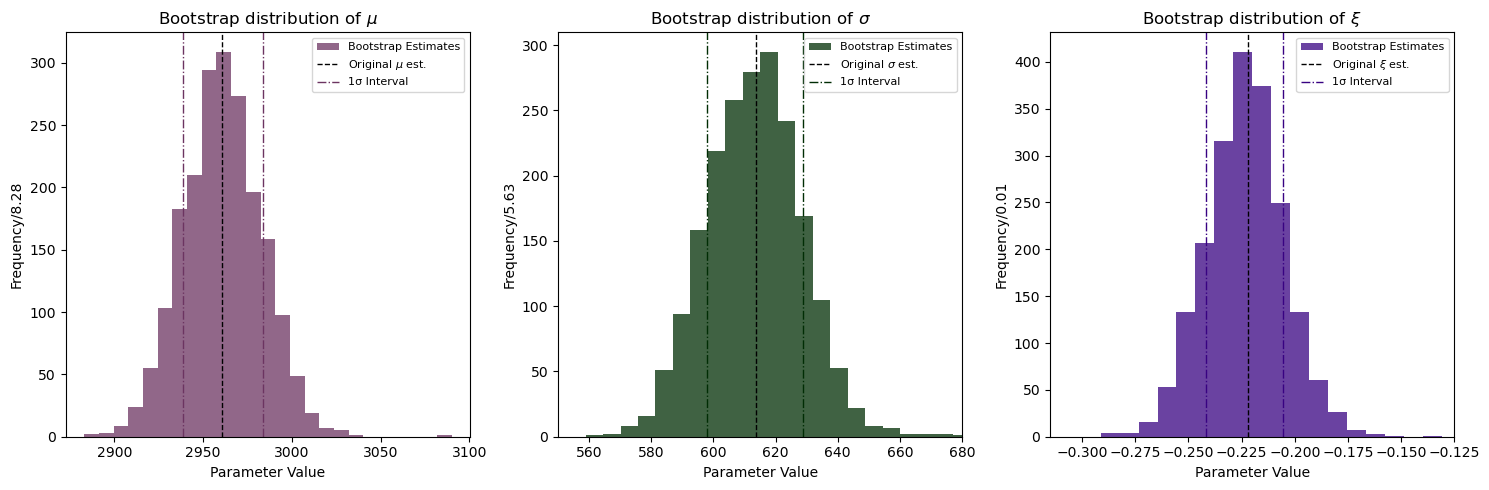

In [16]:
#plot the mu, sigma and xi samples in a histogram:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, (param_boot, param_est, names, sigs, color) in enumerate(zip(boot_samples, params_est, param_names, one_sigs, colors)):
    ax[i].hist(param_boot, bins=25, color=color, alpha=0.75, label = 'Bootstrap Estimates')
    if i == 0:
        ax[i].set_title(r'Bootstrap distribution of $\mu$')
        ax[i].axvline(param_est, color='k', linestyle='dashed', linewidth=1, label = r'Original $\mu$ est.')
    elif i == 1:
        ax[i].set_title(r'Bootstrap distribution of $\sigma$')
        ax[i].axvline(param_est, color='k', linestyle='dashed', linewidth=1, label = r'Original $\sigma$ est.')
        ax[i].set_xlim(550, 680)
    else:
        ax[i].set_title(r'Bootstrap distribution of $\xi$')
        ax[i].axvline(param_est, color='k', linestyle='dashed', linewidth=1, label = r'Original $\xi$ est.')
        ax[i].set_xlim(-0.315, -0.125)
    ax[i].set_xlabel('Parameter Value')
    ax[i].axvline(sigs[0], color=color, linestyle='-.', linewidth=1, label = '1σ Interval')
    ax[i].axvline(sigs[1], color=color, linestyle='-.', linewidth=1)
    bin_width = (max(param_boot) - min(param_boot)) / 25
    ax[i].set_ylabel(f'Frequency/{bin_width:.2f}')
    ax[i].legend(loc = 'upper right', fontsize = 8)
plt.tight_layout()
plt.show()



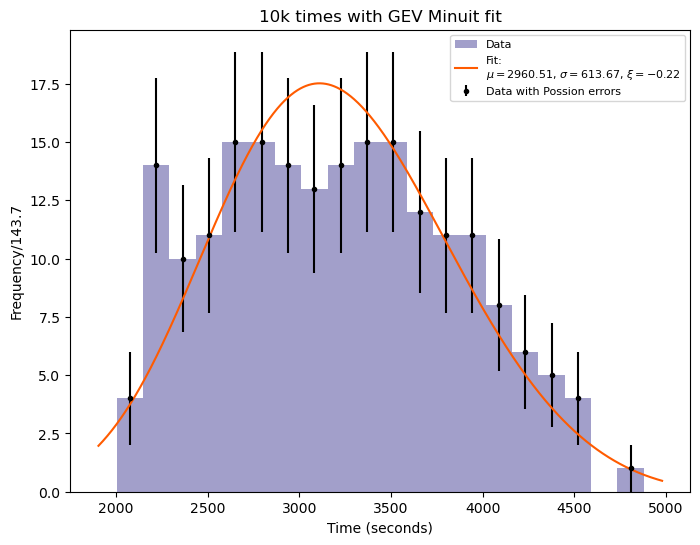

In [17]:
#Plot the data and the fitted GEV distribution:
def plot_gev_fit(x_samples, Nbins, mu, sigma, xi):
    counts, bin_edges = np.histogram(x_samples, bins=Nbins)
    x = 0.5*(bin_edges[:-1] + bin_edges[1:])[counts > 0]
    y = counts[counts > 0]
    sy = np.sqrt(counts[counts > 0])   
    binwidth = bin_edges[1] - bin_edges[0]

    x_fit = np.linspace(min(x_samples)-100, max(x_samples)+100, 1000)
    y_fit = gev_model(x_fit, mu, sigma, xi) * len(x_samples) * binwidth  # Scale by total count and bin width

    fig, ax = plt.subplots(figsize=(8,6))
    ax.errorbar(x, y, yerr=sy, fmt='.k', label='Data with Possion errors')
    ax.hist(x_samples, bins=Nbins, histtype='stepfilled', alpha = 0.5, color='xkcd:blueberry', label='Data')
    ax.plot(x_fit, y_fit, '-', color = 'xkcd:bright orange', label=rf'Fit:' + '\n' + rf'$\mu={mu:.2f}$, $\sigma={sigma:.2f}$, $\xi={xi:.2f}$')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel(f'Frequency/{binwidth:.1f}')
    ax.set_title('10k times with GEV Minuit fit')
    ax.legend(fontsize = 8)
    plt.show()
    return

plot_gev_fit(times_10k_seconds, Nbins=20, mu=mu_est, sigma=sigma_est, xi=xi_est)

## Problem 1b

In [18]:
#Find time of SAG
last_names = times_10k['Last Name'].values
id_SAG= np.where(last_names == 'SomethingAboutGoats')[0][0]
time_SAG = times_10k_seconds[id_SAG]

In [19]:
#Findting probability of running at time slower than SAG using quad (only defined to t >= 0): 
prob_faster_than_SAG = quad(gev_model, 0, time_SAG, 
                             args=(mu_est, sigma_est, xi_est))[0]
print(f"P(time < SAG): {1-prob_faster_than_SAG}")

P(time < SAG): 0.19855597454680352


In [20]:
#Using our data: 
prob_faster_than_SAG_empirical = np.sum((times_10k_seconds < time_SAG))/len(times_10k_seconds)
print(f"Empirical P(time < SAG): {1-prob_faster_than_SAG_empirical:.4f}")

Empirical P(time < SAG): 0.2323


In [73]:
#Find difference
percentwise = ((1-prob_faster_than_SAG)-(1-prob_faster_than_SAG_empirical))/(1-prob_faster_than_SAG_empirical)
print(percentwise)

-0.14534602260288942


Any smart way to compare? 

## Problem 1c

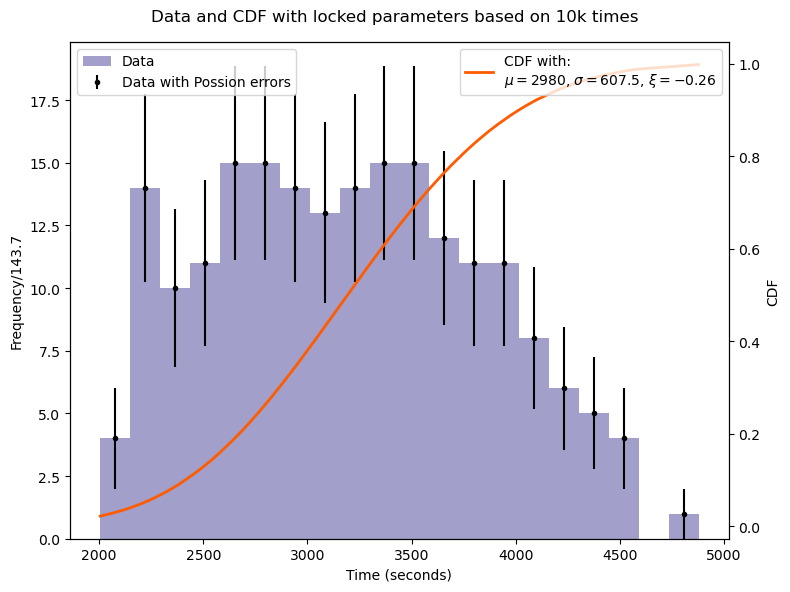

In [19]:
mu_c, sigma_c, xi_c = 2980, 607.5, -0.26
#Calcualate the CDF and scale it to the number of samples (for plotting): 
cdf_c = np.array([quad(gev_model, 0, t, args=(mu_c, sigma_c, xi_c))[0] for t in times_10k_seconds])

def plot_gev_cdf(samples, cdf_values, Nbins, mu_c, sigma_c, xi_c):

    counts, bin_edges = np.histogram(samples, bins=Nbins)
    bin_width = bin_edges[1] - bin_edges[0]
    x = 0.5*(bin_edges[:-1] + bin_edges[1:])[counts > 0]
    y = counts[counts > 0]
    sy = np.sqrt(counts[counts > 0])

    fig, ax1 = plt.subplots(figsize=(8,6))
    ax1.hist(times_10k_seconds, bins=Nbins, histtype='stepfilled', alpha=0.5, color='xkcd:blueberry', label='Data')
    ax1.errorbar(x, y, yerr=sy, fmt='.k', label='Data with Possion errors')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel(f'Frequency/{bin_width:.1f}', color='k')
    ax1.tick_params(axis='y', labelcolor='k')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(np.sort(times_10k_seconds), cdf_c[np.argsort(times_10k_seconds)], '-', color = 'xkcd:bright orange', linewidth=2, label=rf'CDF with:'+ '\n' +  rf'$\mu={mu_c}$, $\sigma={sigma_c}$, $\xi={xi_c}$')
    ax2.set_ylabel('CDF', color='k')
    ax2.tick_params(axis='y', labelcolor='k')
    ax2.legend(loc='upper right')


    fig.suptitle('Data and CDF with locked parameters based on 10k times')
    fig.tight_layout()
    plt.show()
    return

plot_gev_cdf(times_10k_seconds, cdf_c, Nbins=20, mu_c=mu_c, sigma_c=sigma_c, xi_c=xi_c)

In [20]:
#Probablity of getting a time faster than the fastest: 
fastest_time = np.min(times_10k_seconds)
prob_faster_than_fastest = quad(gev_model, 0, fastest_time, args=(mu_c, sigma_c, xi_c))[0]
print(f"P(time < fastest) using given values for mu, sigma, xi: {prob_faster_than_fastest:.3f}")

P(time < fastest) using given values for mu, sigma, xi: 0.022


## Problem 2

In [21]:
alpha_val, beta_val = 2,2
def pdf_gamma(x, alpha, beta):
    num = beta**alpha * x**(alpha - 1) * np.exp(-beta * x)
    denom = gamma(alpha)
    return num/denom

def normalized_gamma(x, alpha, beta, xmin, xmax):
    norm = quad(pdf_gamma, xmin, xmax, args=(alpha, beta))[0]
    return pdf_gamma(x, alpha, beta) / norm

In [22]:
def prior_func(x):
    N= 2.93
    if (x>0) and (x<=1.6):
        return 1/N
    if (x>1.6) and (x<=2.1):
        return 2.66/N
    if (x<=0) or (x>2.1):
        return 0

In [23]:
xvals = np.linspace(0, 4, 1000)
likelihood_vals = normalized_gamma(xvals, 2, 2, 0, 4)
prior_vals = np.array([prior_func(x) for x in xvals])

In [24]:
posterior_vals = likelihood_vals * prior_vals
norm_post = quad(lambda x: normalized_gamma(x, 2, 2, 0, 4) * prior_func(x), 0, 4)[0]
posterior_vals /= norm_post


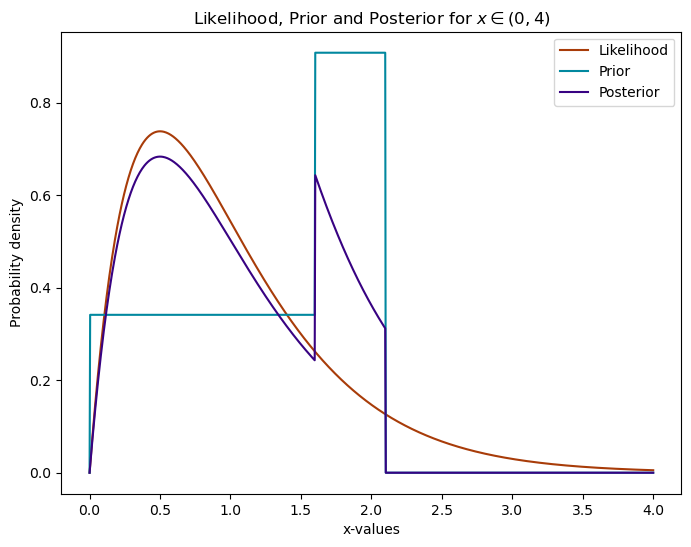

In [25]:
#Plot likelihood, prior and posterior:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(xvals, likelihood_vals, label='Likelihood', color='xkcd:rust')
ax.plot(xvals, prior_vals, label='Prior', color='xkcd:teal blue')
ax.plot(xvals, posterior_vals, label='Posterior', color='xkcd:indigo')
ax.set_xlabel('x-values')
ax.set_ylabel('Probability density')
ax.set_title(r'Likelihood, Prior and Posterior for $x \in (0, 4)$')
ax.legend()
plt.show()

In [26]:
#Find the most likely value of x using the posterior distribution:
most_likely_x = xvals[np.argmax(posterior_vals)]
print(f'Most likely value of x according to the posterior: {most_likely_x:.3f}')

#And the posterior value at said x: 
posterior_at_most_likely_x = posterior_vals[np.argmax(posterior_vals)]
print(f'Posterior value at most likely x: {posterior_at_most_likely_x:.4f}')

Most likely value of x according to the posterior: 0.501
Posterior value at most likely x: 0.6833


## Problem 3

In [27]:
#For plotting. 
from matplotlib.legend_handler import HandlerBase
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

class HandlerImage(HandlerBase):
    def __init__(self, image, zoom=0.15):
        super().__init__()
        self.image = image
        self.zoom = zoom
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        imagebox = OffsetImage(self.image, zoom=self.zoom)
        ab = AnnotationBbox(imagebox,
                            (xdescent + width/2, ydescent + height/2),
                            frameon=False, xycoords=trans)
        return [ab]

# create a dummy handle for the pirate image
pirate_handle = object()

pirate = mpimg.imread('pirate.png')
pirate2 = np.rot90(pirate, k=-1)
pirate3 = np.rot90(pirate, k=1)
x0_pir, y0_pir = -4, 4.5   # center
x0_pir2, y0_pir2 = 5.5, 1.2   # center
x0_pir3, y0_pir3 = -5.8, -2.0   # center
w_pir, h_pir = 1.0, 1.0      # size in plot units

extent_pir = [x0_pir - w_pir/2, x0_pir + w_pir/2, y0_pir - h_pir/2, y0_pir + h_pir/2]
extent_pir2 = [x0_pir2 - w_pir/2, x0_pir2 + w_pir/2, y0_pir2 - h_pir/2, y0_pir2 + h_pir/2]
extent_pir3 = [x0_pir3 - w_pir/2, x0_pir3 + w_pir/2, y0_pir3 - h_pir/2, y0_pir3 + h_pir/2]

In [28]:
r_island = 5 #km
r_maxmovement = 0.2 #km/day

@njit
def direction(angle):
    return np.array([np.cos(angle), np.sin(angle)])

In [ ]:
@njit
def single_crab(ndays, start_pos):
    positions = np.zeros((ndays+1, 2))
    positions[0] = start_pos

    for day in range(1, ndays+1):
        trial_angle = np.random.uniform(0, 2 * np.pi)
        last_pos = positions[day - 1]
        movement = r_maxmovement * direction(trial_angle)
        new_pos = last_pos + movement

        if np.linalg.norm(new_pos) > r_island:

            # Solve |last_pos + t*movement|^2 = r_island^2
            a = np.dot(movement, movement)
            b = 2 * np.dot(last_pos, movement)
            c = np.dot(last_pos, last_pos) - r_island**2

            discriminant = b**2 - 4*a*c
            if discriminant >= 0:
                t = (-b + np.sqrt(discriminant)) / (2*a)
            if t < 0.0:
                t = 0.0
            elif t > 1.0:
                t = 1.0
            new_position = last_pos + t*movement
        else:
            new_position = new_pos

        positions[day] = new_position
    return positions

singlecrab_pos = single_crab(200, start_pos=np.array([3.6, -2.0]))

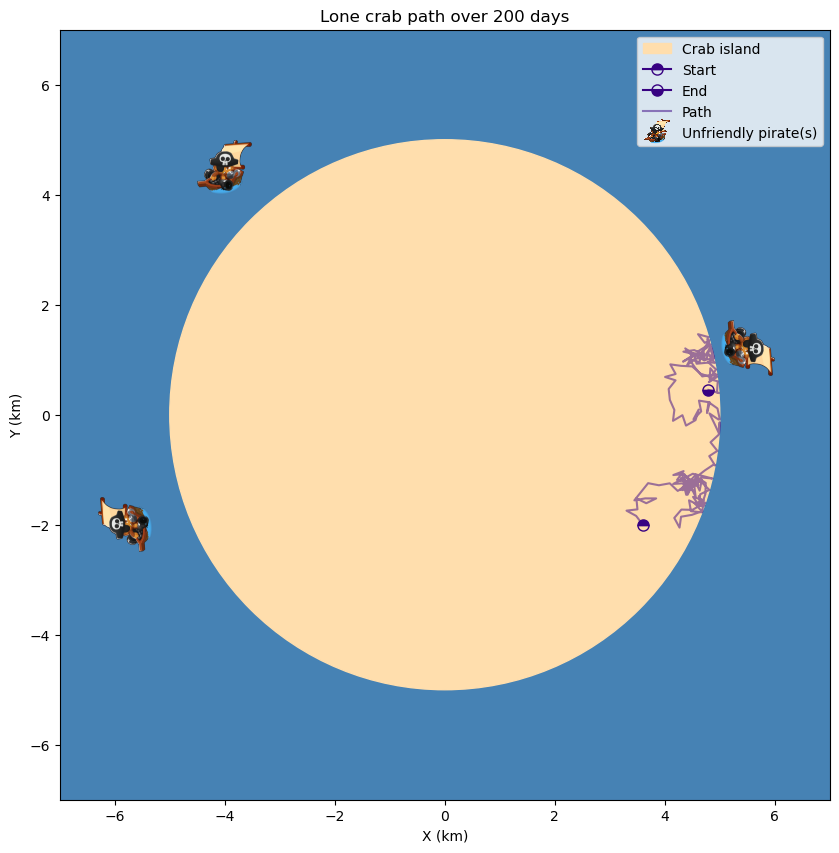

In [30]:
#plot signle crab movement and draw island using a circle:
fig, ax = plt.subplots(figsize=(10,10))
island = plt.Circle((0, 0), r_island, color="navajowhite", zorder=1, label="Crab island")
ax.add_patch(island)
ax.plot(singlecrab_pos[0, 0], singlecrab_pos[0, 1], marker='o', markersize = 8, color='xkcd:indigo', fillstyle = 'top', label='Start')
ax.plot(singlecrab_pos[-1, 0], singlecrab_pos[-1, 1], marker='o', markersize = 8, color='xkcd:indigo', fillstyle = 'bottom', label='End')
ax.plot(singlecrab_pos[:, 0], singlecrab_pos[:, 1], '-',  color = 'xkcd:indigo', alpha = 0.5, label='Path')
ax.set_xlabel('X Position (km)')
ax.set_ylabel('Y Position (km)')
ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.set_title('Lone crab path over 200 days')
ax.imshow(pirate, extent=extent_pir, zorder=4)
ax.imshow(pirate2, extent=extent_pir2, zorder=4)
ax.imshow(pirate3, extent=extent_pir3, zorder=4)
ax.legend(loc='upper right')
handles, labels = ax.get_legend_handles_labels()
handles.append(pirate_handle)
labels.append("Unfriendly pirate(s)")

ax.legend(handles, labels, handler_map={pirate_handle: HandlerImage(pirate, zoom=0.02)}, loc='upper right')

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_facecolor('steelblue')

plt.show()

## Problem 3b

In [31]:
def single_crab_untilhit(start_pos):
    positions = np.zeros((1, 2))
    positions[0] = start_pos
    day = 0
    hit_boundary = False

    while not hit_boundary:
        day += 1 
        trial_angle = np.random.uniform(0, 2 * np.pi)
        last_pos = positions[day - 1]
        movement = r_maxmovement * direction(trial_angle)
        new_pos = last_pos + movement

        if np.linalg.norm(new_pos) > r_island:  
            a = np.dot(movement, movement)
            b = 2 * np.dot(last_pos, movement)
            c = np.dot(last_pos, last_pos) - r_island**2

            discriminant = b**2 - 4*a*c
            if discriminant >= 0:
                t = (-b + np.sqrt(discriminant)) / (2*a)
            if t < 0.0:
                t = 0.0
            elif t > 1.0:
                t = 1.0
            new_position = last_pos + t*movement
            hit_boundary = True
        else:
            new_position = new_pos

        positions = np.vstack([positions, new_position])  

    return positions


In [32]:
def dist_traveled(positions):
    return np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1))

N_exp = 501
positions_list = []
for _ in range(N_exp):
    pos_i = single_crab_untilhit(np.array([3.6, -2.0]))
    positions_list.append(pos_i)
    

In [33]:
distances = [dist_traveled(positions_list[i]) for i in range(N_exp)]

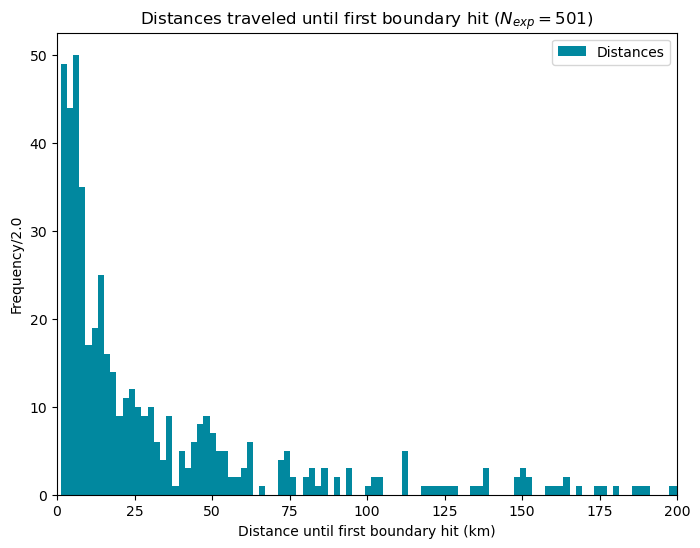

In [63]:
#Plot distances: 
no_bins = (np.max(distances) - np.min(distances)) / 2
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(distances, bins=int(no_bins), histtype='stepfilled', alpha=1, color='xkcd:teal blue', label='Distances')
ax.set_xlabel('Distance until first boundary hit (km)')
ax.set_ylabel(f'Frequency/{((np.max(distances)-np.min(distances))/no_bins):.1f}')
ax.set_title(r'Distances traveled until first boundary hit ($N_{exp}=501$)')
ax.set_xlim(0, 200)
ax.legend();

## Problem 3c

In [38]:
start_pos = pd.read_csv('CrabStartPositions.txt', header=None, delimiter = ' ').values

In [39]:
@njit
def winning_odds(M1, M2):
    denom = M1**2 + M2**2
    return M1**2 / denom, M2**2 / denom

In [ ]:
@njit
def crab_battle(n_days, n_crabs, start_positions, start_mass):
    masses = np.full(n_crabs, start_mass)
    alive = np.ones(n_crabs, dtype=np.bool_)
    positions = np.zeros((n_crabs, n_days + 1, 2))
    positions[:, 0, :] = start_positions

    for day in range(1, n_days + 1):
        day_pos = np.zeros((n_crabs, 2))
        for j in range(n_crabs):
            if alive[j]:
                one_day_path = single_crab(1, start_pos=positions[j, day - 1, :])
                day_pos[j] = one_day_path[-1]
            else:
                day_pos[j] = positions[j, day - 1, :]

        battle_pairs = []
        alive_ids = np.where(alive)[0]
        for a_idx in range(len(alive_ids)):
            i = alive_ids[a_idx]
            for b_idx in range(a_idx + 1, len(alive_ids)):
                j = alive_ids[b_idx]
                dist = np.linalg.norm(day_pos[i] - day_pos[j])
                if dist <= 0.175:
                    battle_pairs.append((dist, i, j))
                # Sort by distance
        for i in range(len(battle_pairs)):
            for j in range(i + 1, len(battle_pairs)):
                if battle_pairs[j][0] < battle_pairs[i][0]:
                    battle_pairs[i], battle_pairs[j] = battle_pairs[j], battle_pairs[i]

        for dist, i, j in battle_pairs:
            if not alive[i] or not alive[j]:  # Skip if either dead
                continue
            
            # Determine which crab is larger
            if masses[i] >= masses[j]:
                larger_id = i
                smaller_id = j
                odds_larger, odds_smaller = winning_odds(masses[i], masses[j])
            else:
                larger_id = j
                smaller_id = i
                odds_larger, odds_smaller = winning_odds(masses[j], masses[i])
            
            u = np.random.uniform()
            
            if u < odds_larger:
                # Larger crab wins
                masses[larger_id] += masses[smaller_id]
                masses[smaller_id] = 0.0
                alive[smaller_id] = False


        positions[:, day, :] = day_pos

    survivor_mass = masses[alive]
    total_mass = np.sum(survivor_mass)
    if total_mass != 20.0:
        print("Warning: Total survivor mass is " + str(total_mass) + " kg, expected 20 kg.")
    

    return positions, survivor_mass, alive

In [67]:
trial_pos, trial_mass, trial_alive = crab_battle(n_days=200, n_crabs=20, start_positions=start_pos, start_mass=1.0)

In [49]:
print(np.sum(trial_alive), "survivors left after the battle")

11 survivors left after the battle


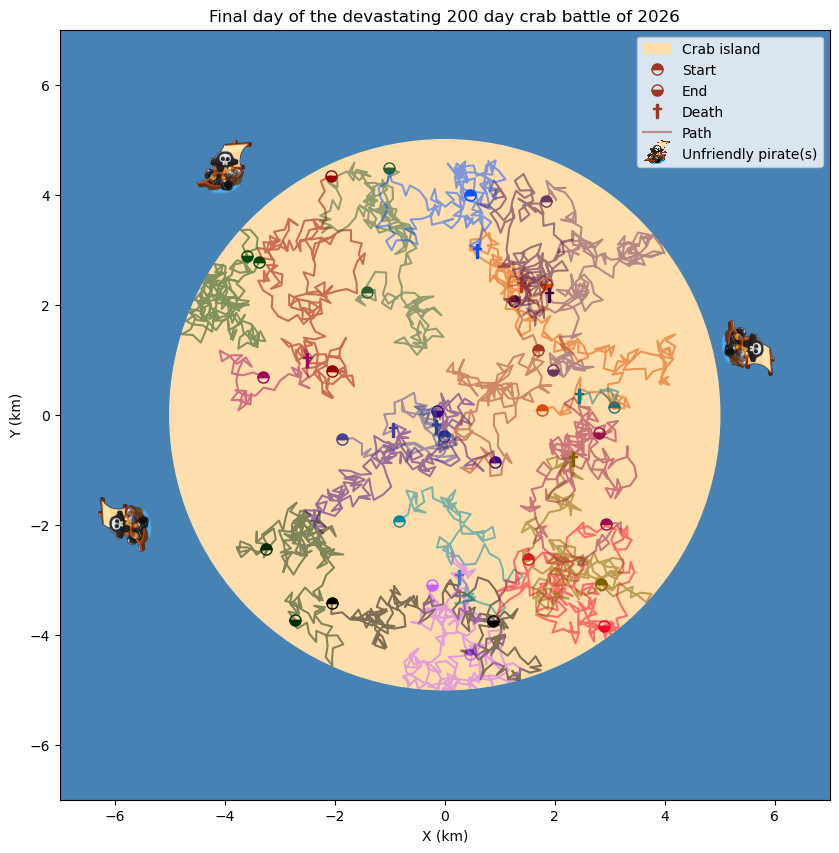

In [50]:
fig, ax = plt.subplots(figsize=(10,10))
island = plt.Circle((0, 0), r_island, color="navajowhite", zorder=1, label="Crab island")
ax.add_patch(island)

dead_labeled = False
for idx in range(len(trial_alive)):
    pos = trial_pos[idx]
    is_dead = not trial_alive[idx]
    label_dead = (is_dead and not dead_labeled)

    ax.plot(pos[0, 0], pos[0, 1], marker="o", markersize = 8, color = colors[idx], linestyle = 'None', fillstyle="top",
             label="Start" if label_dead else None, zorder = 1)
    ax.plot([], [], marker='o', markersize = 8, linestyle = 'None', color = colors[idx],
            fillstyle = 'bottom', label="End" if label_dead else None)
    if trial_alive[idx] == False:
        ax.plot(pos[-1, 0], pos[-1, 1], marker='$\\dagger$', markersize = 10, linestyle = 'None', color = colors[idx],
            label="Death" if label_dead else None)
    elif trial_alive[idx] == True: 
        ax.plot(pos[-1, 0], pos[-1, 1], marker='o', markersize = 8, linestyle = 'None', fillstyle = 'bottom', color = colors[idx],
            label="End" if label_dead else None)
    ax.plot(pos[:, 0], pos[:, 1], linestyle="-", color = colors[idx], alpha=0.5,
            label="Path" if label_dead else None)
    
    if label_dead:
        dead_labeled = True


ax.imshow(pirate, extent=extent_pir, zorder=4)
ax.imshow(pirate2, extent=extent_pir2, zorder=4)
ax.imshow(pirate3, extent=extent_pir3, zorder=4)
handles, labels = ax.get_legend_handles_labels()
handles.append(pirate_handle)
labels.append("Unfriendly pirate(s)")

ax.legend(handles, labels, handler_map={pirate_handle: HandlerImage(pirate, zoom=0.02)}, loc='upper right')

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_facecolor('steelblue')
ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.set_title('Final day of the devastating 200 day crab battle of 2026')
#ax.legend(loc = 'upper left')
plt.show()

In [51]:
@njit
def run_crab_experiments(n_exp):
    max_masses = []
    survivors = []
    for _ in range(n_exp):
        crab_20, masses_20, alive_20 = crab_battle(200, 20, start_pos, 1)
        max_mass = np.max(masses_20)
        no_alive = np.sum(alive_20)

        max_masses.append(max_mass)
        survivors.append(no_alive)
        
    return max_masses, survivors

max_masses_after_Nexp, no_of_survivors_after_Nexp = run_crab_experiments(n_exp=10000)


print(f"Max masses after 10000 experiments: {max_masses_after_Nexp}")
print(f"Number of survivors after 10000 experiments: {no_of_survivors_after_Nexp}")

Max masses after 10 experiments: [5, 4, 5, 3, 3, 3, 3, 3, 3, 3, 3, 4, 10, 4, 4, 3, 3, 4, 7, 3, 3, 4, 4, 4, 4, 3, 3, 2, 3, 3, 4, 6, 3, 2, 3, 4, 4, 5, 3, 4, 3, 5, 3, 4, 3, 4, 3, 3, 4, 4, 3, 4, 6, 6, 5, 3, 3, 3, 4, 4, 4, 3, 4, 3, 5, 4, 6, 6, 3, 5, 3, 3, 4, 2, 4, 4, 4, 7, 3, 3, 5, 2, 5, 5, 4, 4, 3, 3, 3, 3, 3, 6, 3, 5, 5, 5, 6, 3, 4, 2, 5, 4, 3, 3, 3, 3, 3, 3, 4, 3, 4, 6, 3, 3, 5, 6, 4, 3, 3, 4, 4, 5, 3, 3, 3, 4, 2, 3, 3, 3, 3, 4, 3, 4, 3, 3, 3, 4, 5, 4, 5, 4, 3, 4, 5, 3, 4, 4, 4, 2, 6, 4, 3, 4, 3, 4, 2, 3, 5, 3, 3, 4, 3, 4, 3, 3, 4, 4, 2, 3, 3, 2, 4, 5, 4, 2, 2, 3, 3, 4, 3, 2, 4, 3, 5, 2, 4, 3, 4, 5, 2, 4, 6, 3, 3, 4, 4, 3, 3, 3, 2, 4, 4, 4, 4, 4, 2, 3, 3, 3, 4, 4, 3, 3, 4, 4, 8, 2, 4, 4, 4, 3, 4, 4, 3, 3, 4, 4, 6, 3, 3, 4, 3, 4, 3, 5, 5, 3, 3, 3, 7, 3, 2, 3, 3, 3, 4, 2, 3, 3, 4, 3, 3, 3, 4, 4, 3, 3, 3, 3, 4, 4, 4, 3, 3, 4, 6, 6, 4, 3, 3, 4, 4, 4, 4, 3, 4, 5, 3, 3, 5, 5, 4, 4, 4, 3, 3, 3, 5, 4, 5, 4, 5, 3, 3, 4, 3, 4, 3, 3, 5, 4, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 3, 6, 4, 5, 4, 3, 4, 3, 4,

In [52]:
mode_max_mass = mode(max_masses_after_Nexp, keepdims=False)
max_mass_value = float(mode_max_mass.mode)
print(f"Most common max mass after 10 experiments: {max_mass_value:.2f} kg")

mode_survivors = mode(no_of_survivors_after_Nexp, keepdims=False)
survivor_value = int(mode_survivors.mode)
print(f"Most common number of survivors after 10 experiments: {survivor_value}")

Most common max mass after 10 experiments: 3.00 kg
Most common number of survivors after 10 experiments: 13


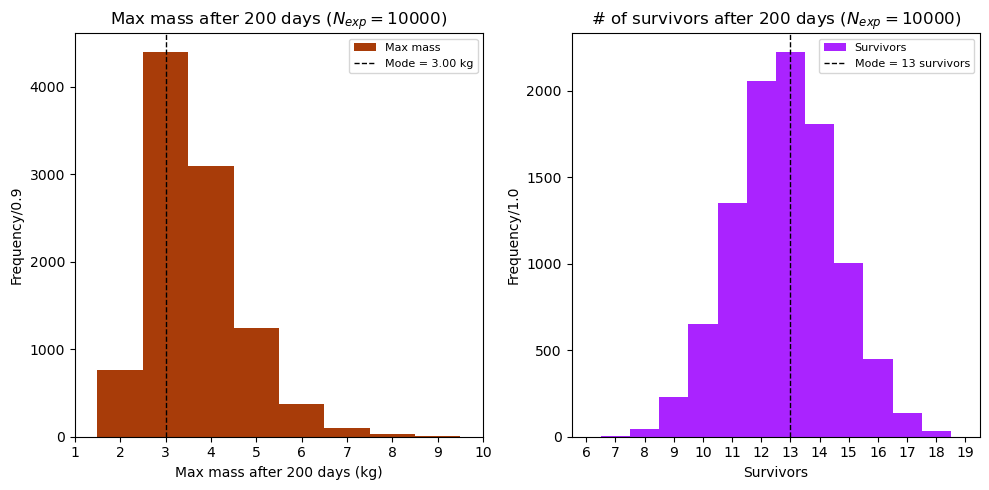

In [60]:
#Plot the resulting distributions: 
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(max_masses_after_Nexp, bins=9, range = (0.5, 9.5), histtype='stepfilled', color='xkcd:rust', label='Max mass')
ax[0].axvline(max_mass_value, color='k', linestyle='dashed', linewidth=1, label=f'Mode = {max_mass_value:.2f} kg')
ax[0].set_xlabel('Max mass after 200 days (kg)')
ax[0].set_ylabel(f'Frequency/{((max(max_masses_after_Nexp)-min(max_masses_after_Nexp))/9):.1f}')
ax[0].set_xlim(1, 10)
ax[0].legend(loc='upper right', fontsize = 8)
ax[0].set_title(r'Max mass after 200 days ($N_{exp}=10000$)')

ax[1].hist(no_of_survivors_after_Nexp, bins=14,  range = (5.5, 19.5), histtype='stepfilled', color='xkcd:electric purple', label='Survivors')
ax[1].axvline(survivor_value, color='k', linestyle='dashed', linewidth=1, label=f'Mode = {survivor_value} survivors')
ax[1].set_xlabel('Survivors')
ax[1].set_ylabel(f'Frequency/{((max(no_of_survivors_after_Nexp)-min(no_of_survivors_after_Nexp))/14):.1f}')
ax[1].set_title(r'# of survivors after 200 days ($N_{exp}=10000$)')
ax[1].set_xlim(5.5, 19.5)
ax[1].set_xticks(range(6, 20))
ax[1].legend(loc='upper right', fontsize = 8)
plt.tight_layout()
plt.show()


## Problem 3d

In [ ]:
@njit
def crab_battle_until10(n_crabs, start_positions, start_mass):
    masses = np.full(n_crabs, start_mass)
    alive = np.ones(n_crabs, dtype=np.bool_)

    max_iterations = 10000  # reasonable upper bound
    positions = np.zeros((n_crabs, max_iterations, 2))
    positions[:, 0, :] = start_positions

    day = 0
    no_alive = np.sum(alive)

    while no_alive > 10:
        day += 1
        day_pos = np.zeros((n_crabs, 2))
        for j in range(n_crabs):
            if alive[j]:
                one_day_path = single_crab(1, start_pos=positions[j, day - 1, :])
                day_pos[j] = one_day_path[-1]
            else:
                day_pos[j] = positions[j, day - 1, :]

        battle_pairs = []
        alive_ids = np.where(alive)[0]
        for a_idx in range(len(alive_ids)):
            i = alive_ids[a_idx]
            for b_idx in range(a_idx + 1, len(alive_ids)):
                j = alive_ids[b_idx]
                dist = np.linalg.norm(day_pos[i] - day_pos[j])
                if dist <= 0.175:
                    battle_pairs.append((dist, i, j))
        for i in range(len(battle_pairs)):
            for j in range(i + 1, len(battle_pairs)):
                if battle_pairs[j][0] < battle_pairs[i][0]:
                    battle_pairs[i], battle_pairs[j] = battle_pairs[j], battle_pairs[i]

        for dist, i, j in battle_pairs:
            if not alive[i] or not alive[j]:  # Skip if either dead
                continue
            
            # Determine which crab is larger
            if masses[i] >= masses[j]:
                larger_id = i
                smaller_id = j
                odds_larger, odds_smaller = winning_odds(masses[i], masses[j])
            else:
                larger_id = j
                smaller_id = i
                odds_larger, odds_smaller = winning_odds(masses[j], masses[i])
            
            u = np.random.uniform()
            
            if u < odds_larger:
                # Larger crab wins 
                masses[larger_id] += masses[smaller_id]
                masses[smaller_id] = 0.0
                alive[smaller_id] = False

        positions[:, day, :] = day_pos
        no_alive = np.sum(alive)

    return day

In [55]:
@njit
def run_crab_until10_experiments(n_exp):
    days_until_10 = []
    for _ in range(n_exp):
        day_10 = crab_battle_until10(20, start_pos, 1)
        days_until_10.append(day_10)
    return days_until_10

days_until_10_after_Nexp = run_crab_until10_experiments(n_exp=10000)

In [56]:
#Let find the 1σ interval for the number of days until 10 survivors:
days_lo, days_hi = one_sigma_interval(days_until_10_after_Nexp)

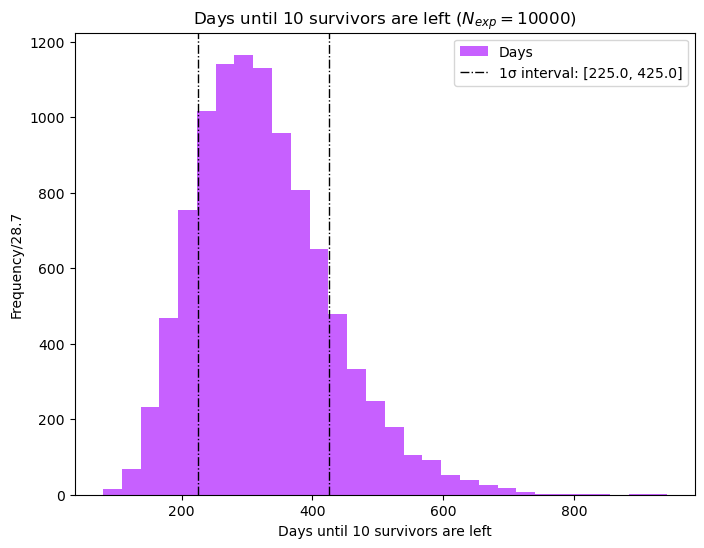

In [57]:
#Plot the distribution of days until 10 survivors are left:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(days_until_10_after_Nexp, bins=30, histtype='stepfilled', alpha=1, color='xkcd:bright lavender', label='Days')
ax.axvline(days_lo, color='k', linestyle='-.', linewidth=1, label=f'1σ interval: [{days_lo}, {days_hi}]')
ax.axvline(days_hi, color='k', linestyle='-.', linewidth=1)
ax.set_xlabel('Days until 10 survivors are left')
ax.set_ylabel(f'Frequency/{((max(days_until_10_after_Nexp)-min(days_until_10_after_Nexp))/30):.1f}')
ax.set_title(r'Days until 10 survivors are left ($N_{exp} = 10000$)')
ax.legend(loc='upper right')
plt.show()
